In [1]:
from utils import *


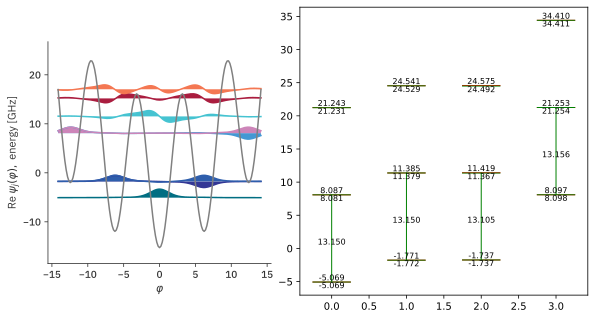

In [23]:
g_strength = 0.3
EJ = 15.265
EC = 4.2
EL = 0.17



qubit_level = 7
osc_level = 10
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
q_evals = qbt.eigenvals()
E_osc = q_evals[3] - q_evals[0]-0.01

osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())

plot_specturum(qbt, osc, hilbertspace)

10.0%. Run time:   0.82s. Est. time left: 00:00:00:07
20.0%. Run time:   1.66s. Est. time left: 00:00:00:06
30.0%. Run time:   2.50s. Est. time left: 00:00:00:05
40.0%. Run time:   3.37s. Est. time left: 00:00:00:05
50.0%. Run time:   4.24s. Est. time left: 00:00:00:04
60.0%. Run time:   5.17s. Est. time left: 00:00:00:03
70.0%. Run time:   6.06s. Est. time left: 00:00:00:02
80.0%. Run time:   6.79s. Est. time left: 00:00:00:01
90.0%. Run time:   7.50s. Est. time left: 00:00:00:00
Total run time:   8.21s
10.0%. Run time:   0.83s. Est. time left: 00:00:00:07
20.0%. Run time:   1.66s. Est. time left: 00:00:00:06
30.0%. Run time:   2.51s. Est. time left: 00:00:00:05
40.0%. Run time:   3.38s. Est. time left: 00:00:00:05
50.0%. Run time:   4.27s. Est. time left: 00:00:00:04
60.0%. Run time:   5.15s. Est. time left: 00:00:00:03
70.0%. Run time:   5.95s. Est. time left: 00:00:00:02
80.0%. Run time:   6.65s. Est. time left: 00:00:00:01
90.0%. Run time:   7.37s. Est. time left: 00:00:00:00
Tota

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

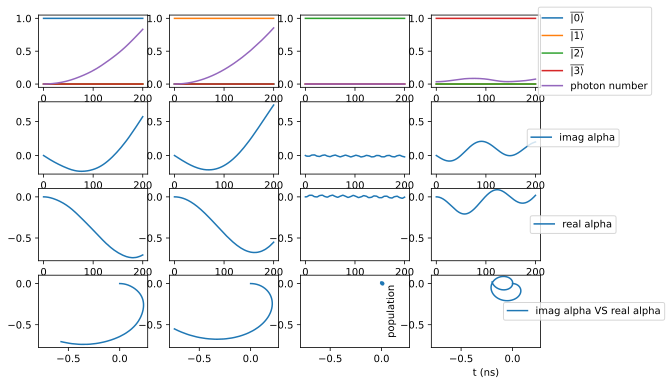

In [22]:


a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )


tot_time = 200
tlist = np.linspace(0, tot_time, tot_time*2)

A_square = 0.0015

def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *A_square * cos

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos]]

kappa = 0.0
decay_term = kappa*a


results = []
for i in range(4):
    temp = solve_with_mesolve(
        H = H_with_drive,
        state0=  qutip.basis(hilbertspace.dimension, product_to_dressed[(i,0)]),
        tlist = tlist,
        # c_ops= [ decay_term],
        options=qutip.Options(store_states=True,nsteps=20000,num_cpus = 7),
        
    )
    results.append(temp)


plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True)

In [15]:
interactive_heatmap(results[0], product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=1999), Output…